# Compare Predictions of Redshift by Masking Percent
The goal of this notebook is to predict redshift values across original and reconstructed images for analysis


## 0.1 Imports
Upload the files from /
storage /
ice-shared /
cs7643 /
shared-group-project-data /
the-space-cats /
the-space-cats-project /
experiments / ...mask_nn

In [ ]:
import h5py

file_path = '/content/data/testing_outputs_best.hdf5'

try:
    with h5py.File(file_path, 'r') as f:
        print(f"Successfully opened HDF5 file: {file_path}")
        print("Keys in the HDF5 file (top-level datasets/groups):")
        for key in f.keys():
            print(f"- {key}")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while trying to read the HDF5 file: {e}")

Successfully opened HDF5 file: /content/data/testing_outputs_best.hdf5
Keys in the HDF5 file (top-level datasets/groups):
- masked_region_map
- original_id
- x_masked_image
- y_recon_image
- y_specz_redshift
- y_target_image
- z_latent_map
- z_latent_vector


## 1.0 Load CNN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import numpy as np
import pandas as pd
from einops import rearrange

# arch from CNN experiments:
class RedshiftCNN(nn.Module):
    def __init__(self, num_channels=5, output_dim=1, input_image_size=(64, 64)):
        super(RedshiftCNN, self).__init__()

        # Input: 5 channels, 64x64 image
        self.conv1 = nn.Conv2d(in_channels=num_channels, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected layers
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(512, 1)

    def forward(self, x):
        # Apply Conv -> ReLU -> Pool for each block
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))

        # Flatten the output for the fully connected layers
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 1.1 Load Trained CNN Weights
make sure you upload the pth file (redshift_cnn_model)

In [ ]:
model_path = '/content/data/redshift_cnn_model.pth'

input_image_size = (64, 64)
model = RedshiftCNN(num_channels=5, output_dim=1, input_image_size=input_image_size)

# Check if CUDA is available and use it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

# model in eval mode
model.eval()

RedshiftCNN(
  (conv1): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

# 2.0 Case Study
Try to get evaluation working for one individual reconstruction and regular

## 2.1 Load Dataset

In [ ]:
import h5py
import numpy as np

hdf5_file_path = '/content/data/testing_outputs_best.hdf5'

with h5py.File(hdf5_file_path, 'r') as f:
    y_target_image_data = f['y_target_image'][()]
    y_recon_image_data = f['y_recon_image'][()]
    y_specz_redshift_data = f['y_specz_redshift'][()]

## 2.2 "De" normalize images
transform images back to their original state, based on the transform applied to the reconstructions

In [ ]:
orig_min = -137.3596649169922
orig_max = 852.43115234375
norm_min = 0.0
norm_max = 1.0

norm_span = norm_max - norm_min
orig_span = orig_max - orig_min

# Revert the min-max normalization
y_recon_image_restored = (y_recon_image_data - norm_min) / norm_span * orig_span + orig_min
y_target_image_restored = (y_target_image_data - norm_min) / norm_span * orig_span + orig_min

print("Images successfully restored to their original scale.")

Images successfully restored to their original scale.


## 2.3 Normalize according to CNN strategy

In [ ]:
import numpy as np
from einops import rearrange

print("\n--- Normalizing Images (per-channel using training stats) ---")

channel_means = np.array([0.21533734, 0.45367402, 0.68543416, 0.8832283, 1.0558323])
channel_stds = np.array([1.0022058, 1.9175421, 3.0707815, 3.8724658, 4.5129385])

print(f"Channel means: {channel_means}")
print(f"Channel stds: {channel_stds}")

# Normalize the datasets using the means and stds
y_target_image_data_normalized = (y_target_image_restored - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')
y_recon_image_data_normalized = (y_recon_image_restored - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')

print("Normalization complete.")


--- Normalizing Images (per-channel using training stats) ---
Channel means: [0.21533734 0.45367402 0.68543416 0.8832283  1.0558323 ]
Channel stds: [1.0022058 1.9175421 3.0707815 3.8724658 4.5129385]
Normalization complete.


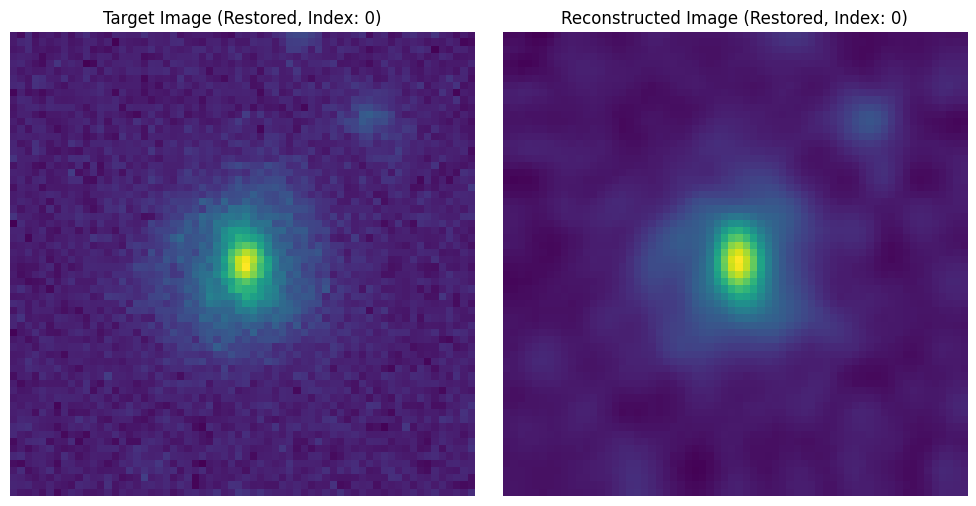

In [ ]:
import matplotlib.pyplot as plt

# Select an index to visualize
idx = 0

# The images likely have 5 channels (C, H, W), so we average across channels (axis=0) to visualize them as 2D.
target_vis = y_target_image_restored[idx].mean(axis=0)
recon_vis = y_recon_image_restored[idx].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(target_vis, cmap='viridis')
axes[0].set_title(f'Target Image (Restored, Index: {idx})')
axes[0].axis('off')

axes[1].imshow(recon_vis, cmap='viridis')
axes[1].set_title(f'Reconstructed Image (Restored, Index: {idx})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2.2 Evaluate Single Data Row

In [ ]:
import numpy as np
import pandas as pd
import torch

# Ensure data is available (assuming it was loaded and normalized in previous cells)
if 'y_target_image_data_normalized' in locals() and 'model' in locals():
    # Select a random index for the sample case study
    num_samples = len(y_specz_redshift_data)
    sample_idx = np.random.randint(0, num_samples)

    # Extract the normalized data for the specific sample
    orig_img_np = y_target_image_data_normalized[sample_idx]
    recon_img_np = y_recon_image_data_normalized[sample_idx]
    actual_redshift = y_specz_redshift_data[sample_idx]

    # Convert to PyTorch tensors, add batch dimension (unsqueeze(0)), and move to device
    orig_img_tensor = torch.from_numpy(orig_img_np).float().unsqueeze(0).to(device)
    recon_img_tensor = torch.from_numpy(recon_img_np).float().unsqueeze(0).to(device)

    # Perform inference
    model.eval()
    with torch.no_grad():
        pred_redshift_orig = model(orig_img_tensor).item()
        pred_redshift_recon = model(recon_img_tensor).item()

    # Calculate Deltas
    delta_orig = pred_redshift_orig - actual_redshift
    delta_recon = pred_redshift_recon - actual_redshift

    # Create a DataFrame for a clean table output matching requested format
    case_study_data = {
        'Metric': [
            'Actual Redshift',
            'Predicted Redshift',
            'Delta'
        ],
        'y_target_image': [
            actual_redshift,
            pred_redshift_orig,
            delta_orig
        ],
        'y_recon_image': [
            actual_redshift,
            pred_redshift_recon,
            delta_recon
        ]
    }

    comparison_df = pd.DataFrame(case_study_data)

    print("\n--- Redshift Prediction Comparison Table ---")
    print(comparison_df.to_markdown(index=False))
else:
    print("Please ensure the model is loaded and the data is normalized in the previous cells first.")


--- Redshift Prediction Comparison Table ---
| Metric             |   y_target_image |   y_recon_image |
|:-------------------|-----------------:|----------------:|
| Actual Redshift    |        0.0358746 |       0.0358746 |
| Predicted Redshift |        0.125276  |       0.122378  |
| Delta              |        0.0894018 |       0.0865038 |


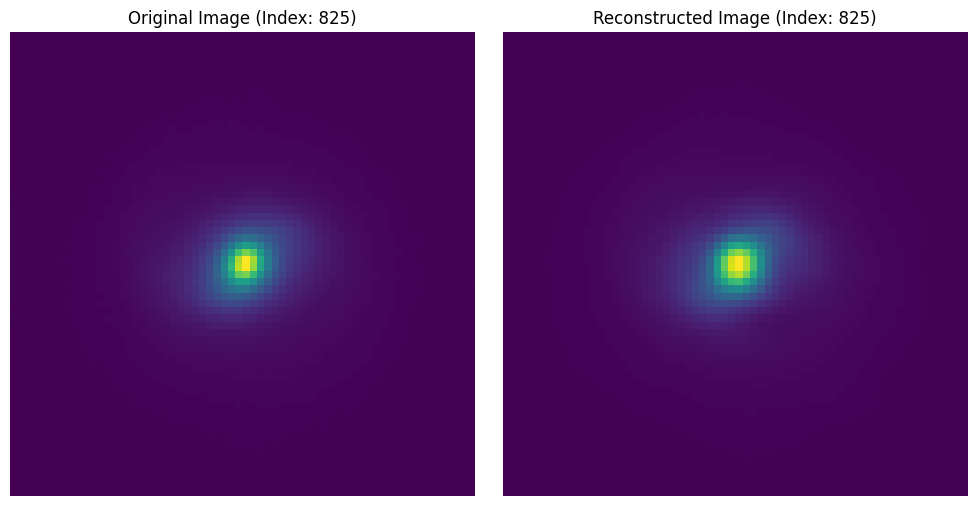

In [ ]:
import matplotlib.pyplot as plt

# Ensure we have the images from the sample case study cell
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# The images have 5 channels (C, H, W). We can visualize the average across all channels.
orig_vis = orig_img_np.mean(axis=0)
recon_vis = recon_img_np.mean(axis=0)

axes[0].imshow(orig_vis, cmap='viridis')
axes[0].set_title(f'Original Image (Index: {sample_idx})')
axes[0].axis('off')

axes[1].imshow(recon_vis, cmap='viridis')
axes[1].set_title(f'Reconstructed Image (Index: {sample_idx})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 3.0 Evaluation for All Images
woo

